# Notebook - Mohammed
Fase 1 – Data Preparation

In deze fase wordt de dataset voorbereid voor verdere analyse.
De data wordt gecontroleerd op structuur, datatypes en mogelijke problemen zoals missende waarden of duplicaten. Daarnaast wordt de datumkolom omgezet naar een bruikbaar formaat en wordt een jaarkolom toegevoegd zodat trends per jaar geanalyseerd kunnen worden.

In [84]:
import pandas as pd
from pathlib import Path

In [85]:
path = Path("../../data/processed/df_v5_clean_final.csv")
df = pd.read_csv(path)
df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
0,2018-01-01,WK003401,22790,3975,2420
1,2019-01-01,WK003401,22875,3945,2415
2,2020-01-01,WK003401,23275,4005,2485
3,2021-01-01,WK003401,23530,4180,2465
4,2022-01-01,WK003401,1635,175,150


De dataset wordt ingeladen vanuit de map data/processed.
Met de functie read_csv() wordt het CSV-bestand omgezet naar een pandas DataFrame.
De functie head() toont de eerste rijen van de dataset zodat gecontroleerd kan worden of de data correct is ingeladen.

# Structuur van de dataset bekijken

In [86]:
df.shape

(237, 5)

In [87]:
df.columns

Index(['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8',
       'k_15Tot25Jaar_9'],
      dtype='object')

In [88]:
df.dtypes

Peildatum           object
Wijk                object
AantalInwoners_5     int64
k_0Tot15Jaar_8       int64
k_15Tot25Jaar_9      int64
dtype: object

In deze stap wordt de structuur van de dataset onderzocht.
shape laat zien hoeveel rijen en kolommen de dataset bevat.
columns toont de namen van de variabelen in de dataset.
dtypes laat zien welk datatype elke kolom heeft.

# Datum omzetten en jaarkolom maken

In [89]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year
df[["Peildatum", "Jaar"]].head()

,Peildatum,Jaar
0,2018-01-01,2018
1,2019-01-01,2019
2,2020-01-01,2020
3,2021-01-01,2021
4,2022-01-01,2022


De kolom Peildatum wordt omgezet naar een datumformaat zodat tijdsanalyses mogelijk zijn.
Daarna wordt een nieuwe kolom Jaar gemaakt door het jaar uit de datum te halen.
Deze kolom maakt het eenvoudiger om veranderingen per jaar te analyseren.

# Missende waarden controleren

In [90]:
num_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"
]
df[["Peildatum", "Jaar"] + num_cols].isna().sum()

Peildatum           0
Jaar                0
AantalInwoners_5    0
k_0Tot15Jaar_8      0
k_15Tot25Jaar_9     0
dtype: int64

In deze stap wordt gecontroleerd of er missende waarden in de dataset voorkomen. Missende waarden kunnen invloed hebben op analyses en modellen, daarom is het belangrijk om deze te controleren.

# Dataset sorteren

In [91]:
df = df.sort_values(["Wijk", "Jaar"])
df[["Wijk", "Jaar"]].head(15)

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022
5,WK003401,2023
6,WK003401,2024
7,WK003401,2025
8,WK003402,2018
9,WK003402,2019


De dataset wordt gesorteerd op wijk en jaar. Hierdoor staan observaties van dezelfde wijk netjes chronologisch onder elkaar. Dit maakt het makkelijker om trends over tijd te analyseren.

# Duplicaten controleren

In [92]:
df.duplicated(subset=["Wijk", "Jaar"]).sum()

0

Hier wordt gecontroleerd of er dubbele rijen bestaan voor dezelfde combinatie van wijk en jaar.
Duplicaten kunnen problemen veroorzaken bij analyses, daarom is het belangrijk om deze te controleren.

In [93]:
df 

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022
...,...,...,...,...,...,...
232,2024-01-01,WK003477,5230,1115,400,2024
233,2025-01-01,WK003477,6135,1300,465,2025
234,2022-01-01,WK003485,90,5,15,2022
235,2023-01-01,WK003485,85,10,10,2023


# Dataset opslaan

In [94]:
df.to_csv("../../data/processed/df_v6_clean_final.csv", index=False)

De opgeschoonde dataset wordt opgeslagen als een nieuwe versie van het bestand.
Deze dataset (df_v6_clean_final.csv) kan vervolgens gebruikt worden voor verdere analyses in de volgende fases van het project.

# Conclusie

In deze fase is de dataset voorbereid voor verdere analyse. De structuur van de data is gecontroleerd en belangrijke kolommen zijn aangepast zodat ze geschikt zijn voor analyse. De datumkolom is omgezet naar een correct datumformaat en er is een nieuwe kolom toegevoegd met het jaar, zodat trends over tijd geanalyseerd kunnen worden. Daarnaast zijn mogelijke problemen zoals missende waarden en duplicaten gecontroleerd. Hierdoor is de dataset klaar voor verdere analyse in de volgende fases van het project.

# Fase 2 – Data Understanding


In [95]:
df = pd.read_csv("../../data/processed/df_v6_clean_final.csv")

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022


# Relatie tussen inwoners en jongeren, scatterplot

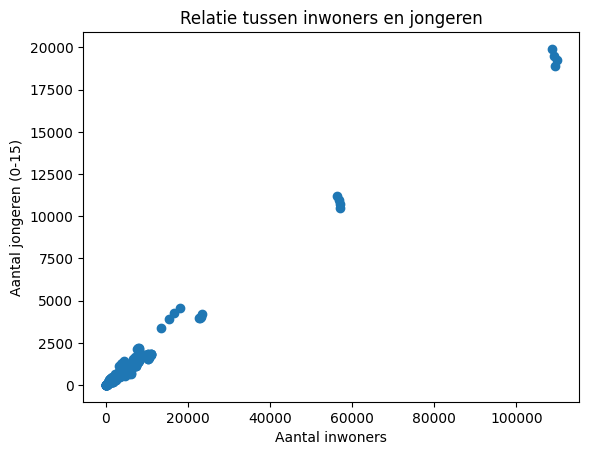

In [96]:
import matplotlib.pyplot as plt


plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xlabel("Aantal inwoners")
plt.ylabel("Aantal jongeren (0-15)")
plt.title("Relatie tussen inwoners en jongeren")
plt.show()

Deze scatterplot toont de relatie tussen het aantal inwoners en het aantal jongeren (0–15 jaar) per wijk.
Elke punt in de grafiek vertegenwoordigt een wijk in een bepaald jaar.
De grafiek laat zien dat wijken met meer inwoners meestal ook meer jongeren hebben.

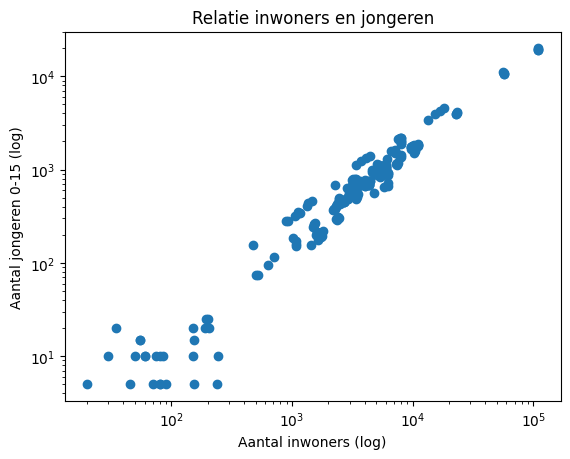

In [97]:
plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Aantal inwoners (log)")
plt.ylabel("Aantal jongeren 0-15 (log)")
plt.title("Relatie inwoners en jongeren")
plt.show()

Deze scatterplot toont dezelfde relatie tussen inwoners en jongeren, maar gebruikt een aangepaste schaal zodat verschillen beter zichtbaar worden. 

# Aantal jongeren per jaar, lijngrafiek

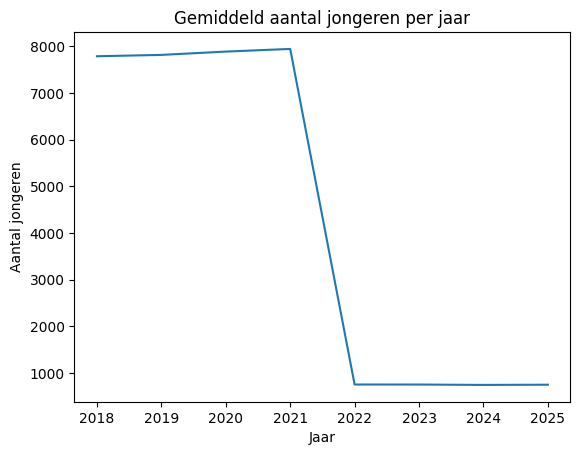

In [98]:
df.groupby("Jaar")["k_0Tot15Jaar_8"].mean().plot()

plt.title("Gemiddeld aantal jongeren per jaar")
plt.xlabel("Jaar")
plt.ylabel("Aantal jongeren")
plt.show()

Deze grafiek toont het gemiddelde aantal jongeren (0–15 jaar) per wijk per jaar. Hiermee kan worden gezien hoe het gemiddelde aantal jongeren zich over de jaren ontwikkelt.

Text(0, 0.5, 'aantal jongeren')

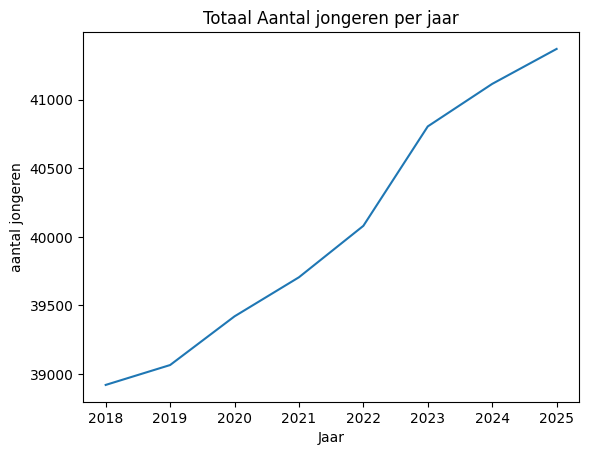

In [99]:
df.groupby("Jaar")["k_0Tot15Jaar_8"].sum().plot()

plt.title("Totaal Aantal jongeren per jaar")
plt.xlabel("Jaar")
plt.ylabel("aantal jongeren")

Deze grafiek toont het totale aantal jongeren (0–15 jaar) per jaar. In tegenstelling tot de vorige grafiek wordt hier niet het gemiddelde gebruikt, maar het totaal van alle wijken samen. Hierdoor wordt duidelijk hoe het totale aantal jongeren zich door de jaren heen ontwikkelt.

# Gemiddeld aantal inwoners per wijk, balkgrafiek

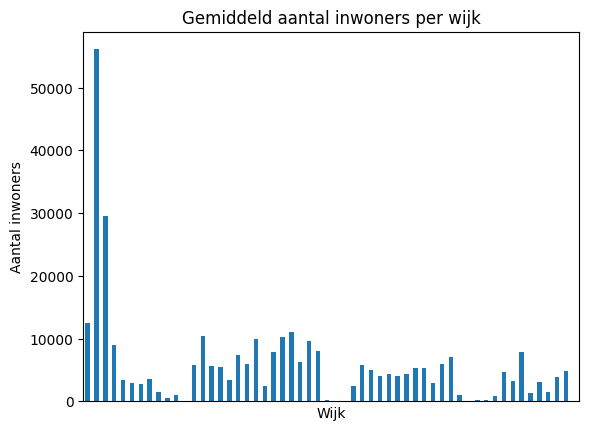

In [100]:
df.groupby("Wijk")["AantalInwoners_5"].mean().plot(kind="bar")

plt.title("Gemiddeld aantal inwoners per wijk")
plt.ylabel("Aantal inwoners")
plt.xticks([]) #verwijder x as labels anders is de balkgraf onleesbaar
plt.show()  

Deze balkgrafiek toont het gemiddelde aantal inwoners per wijk.
De grafiek laat zien dat er grote verschillen bestaan tussen de wijken.
Sommige wijken hebben aanzienlijk meer inwoners dan andere wijken.

# conclusie - Fase 2


De visualisaties geven een beter inzicht in de structuur van de dataset.
De grafieken tonen dat grotere wijken doorgaans ook meer jongeren bevatten en dat het totale aantal jongeren licht toeneemt over de jaren.
Daarnaast is zichtbaar dat het aantal inwoners sterk kan verschillen tussen verschillende wijken.

# Fase 3 - Feature Analyse
Doel van deze fase

In deze fase wordt onderzocht hoe de verschillende variabelen in de dataset met elkaar samenhangen. Door middel van een correlatiematrix wordt bekeken welke variabelen sterk gecorreleerd zijn. Dit helpt bij het identificeren van mogelijke multicollineariteit, wat kan optreden wanneer meerdere variabelen vrijwel dezelfde informatie bevatten.


In [101]:
df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


In deze stap wordt de dataset ingeladen die de gecombineerde features bevat, zoals ratio- en percentagevariabelen. Deze dataset wordt gebruikt om te analyseren hoe de verschillende modelvariabelen met elkaar samenhangen.

# Correlatiematrix berekenen

In [102]:
numeric_df = df.select_dtypes(include=["number"]) #Alleen numerieke variabelen selecteren
corr_matrix = numeric_df.corr()

corr_matrix

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
AantalInwoners_5,1.000000,0.996688,0.998529,0.021245,-0.503183,0.867106,-0.503183,0.867106
k_0Tot15Jaar_8,0.996688,1.000000,0.995371,0.009155,-0.447969,0.868357,-0.447969,0.868357
k_15Tot25Jaar_9,0.998529,0.995371,1.000000,0.007600,-0.511022,0.879091,-0.511022,0.879091
Jaar,0.021245,0.009155,0.007600,1.000000,0.096953,-0.042248,0.096953,-0.042248
pct_0_15,-0.503183,-0.447969,-0.511022,0.096953,1.000000,-0.625288,1.000000,-0.625288
pct_15_25,0.867106,0.868357,0.879091,-0.042248,-0.625288,1.000000,-0.625288,1.000000
Ratio_0_15,-0.503183,-0.447969,-0.511022,0.096953,1.000000,-0.625288,1.000000,-0.625288
Ratio_15_25,0.867106,0.868357,0.879091,-0.042248,-0.625288,1.000000,-0.625288,1.000000


De correlatiematrix toont de sterkte van de relatie tussen de verschillende variabelen. De waarden liggen tussen -1 en 1, waarbij:

1 een perfecte positieve relatie betekent

0 geen relatie betekent

-1 een perfecte negatieve relatie betekent

Deze matrix helpt bij het identificeren van sterke relaties tussen variabelen.

# Correlatiematrix visualiseren

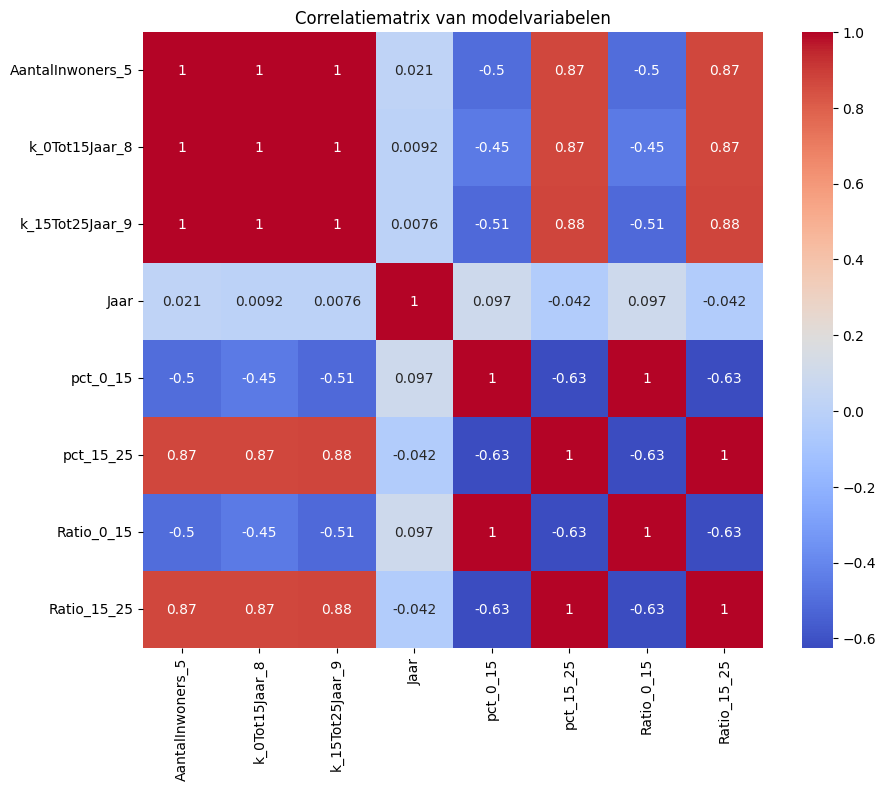

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlatiematrix van modelvariabelen")
plt.show() #heatmap van correlatiematrix laten zien zodat het eenvoudiger te interpreteren is

# Analyse – Multicollineariteit

Uit de correlatiematrix blijkt dat sommige variabelen sterk met elkaar samenhangen. Zo vertonen het aantal inwoners en het aantal jongeren een sterke positieve correlatie, wat logisch is omdat jongeren onderdeel zijn van de totale bevolking. Daarnaast is er een zeer sterke correlatie zichtbaar tussen de percentagevariabelen en de ratio-variabelen. Dit komt doordat deze variabelen gebaseerd zijn op dezelfde onderliggende berekeningen. Dit kan wijzen op multicollineariteit, waarbij meerdere variabelen vrijwel dezelfde informatie bevatten. Bij het bouwen van een model moet hiermee rekening worden gehouden, omdat dergelijke variabelen mogelijk dezelfde informatie bevatten.

# Conclusie – Fase 3
De analyse van de correlatiematrix laat zien dat er sterke relaties bestaan tussen verschillende populatievariabelen. Vooral de ratio en percentagevariabelen vertonen een zeer sterke correlatie omdat ze op dezelfde basisvariabelen zijn gebaseerd. Deze inzichten zijn belangrijk bij het bouwen van een voorspellend model, omdat variabelen die sterk met elkaar samenhangen mogelijk dezelfde informatie bevatten.

# Fase 4 – Modeling
In deze fase onderzoeken we of het totale aantal inwoners van een wijk een goede voorspeller is voor het aantal jongeren tussen 0 en 15 jaar. Hiervoor gebruiken we enkelvoudige lineaire regressie. Dit model probeert een lineaire relatie te vinden tussen het aantal inwoners en het aantal jongeren.

In [104]:
df = pd.read_csv("../../data/processed/df_v11_peildatum_numeriek.csv")
df = df.drop(columns=["jaar"])  #V11 had twee verschillende kolommen voor jaar, hier verwijder ik een van de kolommen 

print(df.columns)
df.head()

df.to_csv("../../data/processed/df_v12_model_ready.csv", index=False) # nieuwe versie van dataset opslaan zodat deze klaar is voor het model

Index(['Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9', 'Jaar',
       'pct_0_15', 'pct_15_25', 'Ratio_0_15', 'Ratio_15_25'],
      dtype='object')


In [105]:
df = pd.read_csv("../../data/processed/df_v12_model_ready.csv")
df.head()

,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


# Model opzetten en evalueren
In deze stap bouwen we een enkelvoudig lineair regressiemodel om te onderzoeken of het totale aantal inwoners van een wijk een goede voorspeller is voor het aantal jongeren tussen 0 en 15 jaar.

Eerst selecteren we alleen de variabelen die we nodig hebben voor het model. Vervolgens splitsen we de dataset in een trainingsset en een testset. De trainingsset wordt gebruikt om het model te trainen, terwijl de testset wordt gebruikt om te controleren hoe goed het model voorspellingen kan maken op nieuwe data.

Daarna trainen we een lineair regressiemodel dat probeert een rechte lijn te vinden tussen het aantal inwoners en het aantal jongeren. Tot slot berekenen we de R²-score, die aangeeft hoe goed het model de variatie in het aantal jongeren kan verklaren.

In [106]:
df_model = df[["AantalInwoners_5", "k_0Tot15Jaar_8"]].dropna()

X = df_model[["AantalInwoners_5"]]
y = df_model["k_0Tot15Jaar_8"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)



R²: 0.9898911069316019


De berekende R²-score is ongeveer 0.99. Dit betekent dat het model bijna alle variatie in het aantal jongeren kan verklaren met behulp van het aantal inwoners. Dit suggereert dat er een sterke positieve relatie bestaat tussen het aantal inwoners en het aantal jongeren. Met andere woorden: wijken met meer inwoners hebben doorgaans ook meer jongeren.

De hoge R² score geeft aan dat het model de relatie tussen deze twee variabelen zeer goed kan beschrijven.

# Visualisatie van het regressiemodel
In deze stap visualiseren we de relatie tussen het aantal inwoners en het aantal jongeren met behulp van een grafiek.

Hiervoor maken we een scatterplot, waarbij elk punt een observatie uit de dataset voorstelt. De x-as toont het aantal inwoners van een wijk en de y-as toont het aantal jongeren tussen 0 en 15 jaar.

Daarnaast tekenen we de regressielijn van het model. Deze lijn laat zien hoe het model de relatie tussen inwoners en jongeren voorspelt. Zo kunnen we visueel beoordelen hoe goed het model bij de data past.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


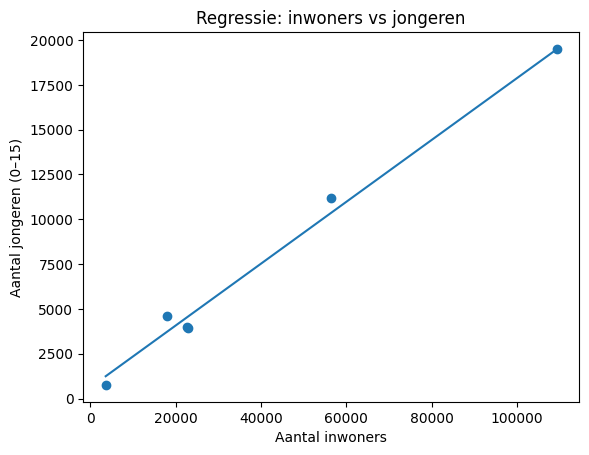

In [107]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(X_test, y_test)

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model.predict(x_line)

plt.plot(x_line, y_line)

plt.xlabel("Aantal inwoners")
plt.ylabel("Aantal jongeren (0–15)")
plt.title("Regressie: inwoners vs jongeren")

plt.show()

In de grafiek zien we verschillende punten die de werkelijke observaties uit de dataset voorstellen. Elk punt geeft een combinatie weer van het aantal inwoners en het aantal jongeren in een wijk. De getekende lijn is de regressielijn van het model. Deze lijn laat zien hoe het model verwacht dat het aantal jongeren verandert wanneer het aantal inwoners toeneemt.

De punten liggen relatief dicht bij de regressielijn, wat aangeeft dat er een duidelijke relatie bestaat tussen het aantal inwoners en het aantal jongeren. Dit ondersteunt ook de hoge R²-score die eerder werd berekend.

# Conclusie Fase - 4
In de grafiek zien we verschillende punten die de werkelijke observaties uit de dataset voorstellen. Elk punt geeft een combinatie weer van het aantal inwoners en het aantal jongeren in een wijk.

De getekende lijn is de regressielijn van het model. Deze lijn laat zien hoe het model verwacht dat het aantal jongeren verandert wanneer het aantal inwoners toeneemt.

De punten liggen relatief dicht bij de regressielijn, wat aangeeft dat er een duidelijke relatie bestaat tussen het aantal inwoners en het aantal jongeren. Dit ondersteunt ook de hoge R²-score die eerder werd berekend.